# Bayesian Logistic Regression Models

## Overview: Create a few BLR models for each umpire with different feature subsets and compare the posterior predictives


---
## Project Workflow:
1. **Install and Import Necessary Libraries**
2. **Create Model Feature Sets**
3. **Create Models**
4. **Sample Posterior & Save Context**
5. **Compare Models**


# Step 1: Install and Import Necessary Libraries


In [55]:
import pymc as pm
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import os
import json
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from collections import Counter

# Step 2: Create Model Feature Sets

In [56]:
# store cleaned data and results
ump1 = pd.read_csv("data/cleaned/Umpire_1_cleaned.csv")
ump2 = pd.read_csv("data/cleaned/Umpire_2_cleaned.csv") 
ump3 = pd.read_csv("data/cleaned/Umpire_3_cleaned.csv")

umpire_datasets = {
    "ump1": ump1,
    "ump2": ump2,
    "ump3": ump3
}

In [57]:
for ump_name, data in umpire_datasets.items():
    # Change bool encoding to ints
    bool_cols = data.select_dtypes(include=['bool']).columns
    data[bool_cols] = data[bool_cols].astype(int)
    
    # add edge distance, how far pitch is from edges of strike zone
    data['edge_distance'] = np.sqrt(
        (np.abs(data['plate_x']) - 0.85)**2 + 
        (np.abs(data['plate_z'] - (data['sz_top'] + data['sz_bot'])/2))**2
    )

In [58]:
# Define priors using a dictionary of {feature_name: prior_mean}
# Model 1: mixed features
mixed = {
    'balls': 0, 'strikes': 0, 'zone': 1, 'pfx_x': 1, 'pfx_z': 0,
    'plate_x': -1, 'plate_z': -1, 'pitch_location': -2,
    'vx0': 0, 'vy0': 0, 'vz0': 0,
    'edge_distance': 1,
    'pitch_type_CH': 1, 'pitch_type_CS': 0, 'pitch_type_CU': 1, 'pitch_type_EP': -1,
    'pitch_type_FA': 1, 'pitch_type_FC': -0.5, 'pitch_type_FF': 1, 'pitch_type_FO': -1,
    'pitch_type_FS': 1, 'pitch_type_KC': -1, 'pitch_type_KN': -1, 'pitch_type_SC': -1,
    'pitch_type_SI': -1, 'pitch_type_SL': -1, 'pitch_type_ST': 1, 'pitch_type_SV': -1,
    'stand_R': 0, 'p_throws_R': 0
}

# Model 2: pitch tyes
pitch_types = {
    'pitch_type_CH': 1,
    'pitch_type_CS': 0,
    'pitch_type_CU': 1,
    'pitch_type_EP': -1,
    'pitch_type_FA': 1,
    'pitch_type_FC': -0.5,
    'pitch_type_FF': 1,
    'pitch_type_FO': -1,
    'pitch_type_FS': 1,
    'pitch_type_KC': -1,
    'pitch_type_KN': -1,
    'pitch_type_SC': -1,
    'pitch_type_SI': -1,
    'pitch_type_SL': -1,
    'pitch_type_ST': 1,
    'pitch_type_SV': -1,
}

# Model 3: physical features
phys_feats = {
    'zone': 1,
    'pfx_x': 1,
    'pfx_z': 0,
    'plate_x': -1,
    'plate_z': -1,
    'pitch_location': -2,
    'vx0': 0,
    'vy0': 0,
    'vz0': 0,
}

feature_sets = {
    "1_all_feats": mixed, #TODO: uncomment
    "2_pitch_types": pitch_types,
    "3_phys_feats": phys_feats
}

# to store results locally
traces = {}
summaries_priors = {}
summaries_posterior = {}

# Step 3: Check Priors

### 3.1 Create Models

In [ ]:
# Define output directory for prior predictive data
output_dir = 'data/prior_pred_y_csvs'
os.makedirs(output_dir, exist_ok=True)

for ump_name, data in umpire_datasets.items():
    for model_name, features in feature_sets.items():
        coords = {'n_obs': range(len(data))}

        with pm.Model(coords=coords) as model:
            print(f"... Starting loop for {model_name}")
            # Intercept
            intercept = pm.Normal('intercept', mu=0, sigma=2)

            # Create priors and store references
            betas = {}
            for name, mu in features.items():
                betas[name] = pm.Normal(f'beta_{name}', mu=mu, sigma=2)

            # Compute logits using vectorized sum
            logits = intercept + sum(betas[name] * data[name] for name in features if name in data.columns)

            # Logistic transformation
            p = pm.Deterministic('p', pm.math.sigmoid(logits))

            # Bernoulli likelihood
            y = pm.Bernoulli('y', p=p, observed=data['error_in_decision'])

            # Prior predictive
            prior_pred = pm.sample_prior_predictive(samples=100) # TODO: switch back to 500 samples

            # see what kind of data the model believes is likely just from the priors.
            summary = az.summary(prior_pred, hdi_prob=0.95)
            beta_values = summary.loc[summary.index.str.startswith("beta_")]

            summaries_priors[model_name] = beta_values

            # Extract prior predictive y values
            prior_predictive_data = prior_pred.prior_predictive['y']
            print(prior_predictive_data)

            # Convert to DataFrame
            reshaped_data = prior_predictive_data.values.flatten().reshape(-1, len(data))
            prior_y_df = pd.DataFrame(reshaped_data)

            # Save to CSV 
            filename = f"{ump_name}_{model_name}_prior_y.csv"
            filepath = os.path.join(output_dir, filename)
            prior_y_df.to_csv(filepath, index=False)
            print(f"Saved prior predictive y values to: {filepath}")

Sampling: [beta_balls, beta_edge_distance, beta_p_throws_R, beta_pfx_x, beta_pfx_z, beta_pitch_location, beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, beta_plate_x, beta_plate_z, beta_stand_R, beta_strikes, beta_vx0, beta_vy0, beta_vz0, beta_zone, intercept, y]


... Starting loop for 1_all_feats


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, intercept, y]


... Starting loop for 2_pitch_types


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pfx_x, beta_pfx_z, beta_pitch_location, beta_plate_x, beta_plate_z, beta_vx0, beta_vy0, beta_vz0, beta_zone, intercept, y]


...

arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pitch_type_CH, beta_pitch_type_CS, beta_pitch_type_CU, beta_pitch_type_EP, beta_pitch_type_FA, beta_pitch_type_FC, beta_pitch_type_FF, beta_pitch_type_FO, beta_pitch_type_FS, beta_pitch_type_KC, beta_pitch_type_KN, beta_pitch_type_SC, beta_pitch_type_SI, beta_pitch_type_SL, beta_pitch_type_ST, beta_pitch_type_SV, intercept, y]


... Starting loop for 2_pitch_types


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)
Sampling: [beta_pfx_x, beta_pfx_z, beta_pitch_location, beta_plate_x, beta_plate_z, beta_vx0, beta_vy0, beta_vz0, beta_zone, intercept, y]


... Starting loop for 3_phys_feats


arviz - WARNING - Shape validation failed: input_shape: (1, 100), minimum_shape: (chains=2, draws=4)


### Print Prior Predictive y Values

In [ ]:
import pandas as pd
import os

# Folder name where the CSVs are stored
csv_dir = 'data/prior_pred_y_csvs'  

# CSV paths for umpire 1, 2, and 3
csv_path1_1 = os.path.join(csv_dir, 'ump1_1_all_feats_prior_y.csv')
csv_path1_2 = os.path.join(csv_dir, 'ump1_2_pitch_types_prior_y.csv')
csv_path1_3 = os.path.join(csv_dir, 'ump1_3_phys_feats_prior_y.csv')

csv_path2_1 = os.path.join(csv_dir, 'ump2_1_all_feats_prior_y.csv')
csv_path2_2 = os.path.join(csv_dir, 'ump2_2_pitch_types_prior_y.csv')
csv_path2_3 = os.path.join(csv_dir, 'ump2_3_phys_feats_prior_y.csv')

csv_path3_1 = os.path.join(csv_dir, 'ump3_1_all_feats_prior_y.csv')
csv_path3_2 = os.path.join(csv_dir, 'ump3_2_pitch_types_prior_y.csv')
csv_path3_3 = os.path.join(csv_dir, 'ump3_3_phys_feats_prior_y.csv')

# Load CSV files into DataFrames for all umpires
df1_1 = pd.read_csv(csv_path1_1)
df1_2 = pd.read_csv(csv_path1_2)
df1_3 = pd.read_csv(csv_path1_3)

df2_1 = pd.read_csv(csv_path2_1)
df2_2 = pd.read_csv(csv_path2_2)
df2_3 = pd.read_csv(csv_path2_3)

df3_1 = pd.read_csv(csv_path3_1)
df3_2 = pd.read_csv(csv_path3_2)
df3_3 = pd.read_csv(csv_path3_3)

# Compute averages for umpire 1
overall_average_1_1 = df1_1.mean(numeric_only=True).mean()
overall_average_1_2 = df1_2.mean(numeric_only=True).mean()
overall_average_1_3 = df1_3.mean(numeric_only=True).mean()

# Compute averages for umpire 2
overall_average_2_1 = df2_1.mean(numeric_only=True).mean()
overall_average_2_2 = df2_2.mean(numeric_only=True).mean()
overall_average_2_3 = df2_3.mean(numeric_only=True).mean()

# Compute averages for umpire 3
overall_average_3_1 = df3_1.mean(numeric_only=True).mean()
overall_average_3_2 = df3_2.mean(numeric_only=True).mean()
overall_average_3_3 = df3_3.mean(numeric_only=True).mean()

# Print results
print("Average Model 1 Umpire 1 (All Features):", overall_average_1_1)
print("Average Model 2 Umpire 1 (Pitch Types):", overall_average_1_2)
print("Average Model 3 Umpire 1 (Phys Features):", overall_average_1_3)

print("Average Model 1 Umpire 2 (All Features):", overall_average_2_1)
print("Average Model 2 Umpire 2 (Pitch Types):", overall_average_2_2)
print("Average Model 3 Umpire 2 (Phys Features):", overall_average_2_3)

print("Average Model 1 Umpire 3 (All Features):", overall_average_3_1)
print("Average Model 2 Umpire 3 (Pitch Types):", overall_average_3_2)
print("Average Model 3 Umpire 3 (Phys Features):", overall_average_3_3)


### 3.2 Beta Visualizations 
not needed for calculations below. Just a sanity check of spread of priors, data actually in data set.

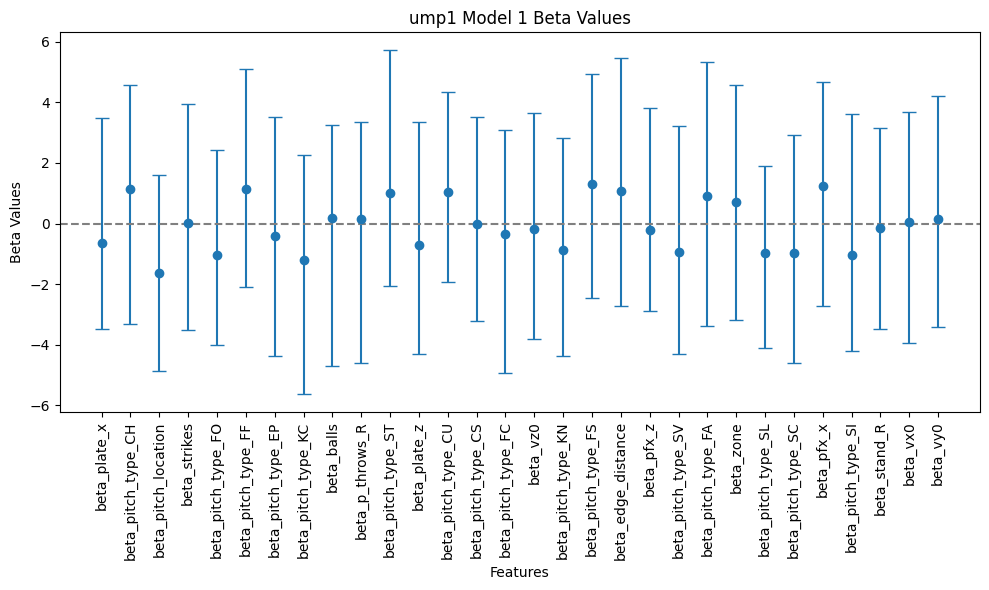

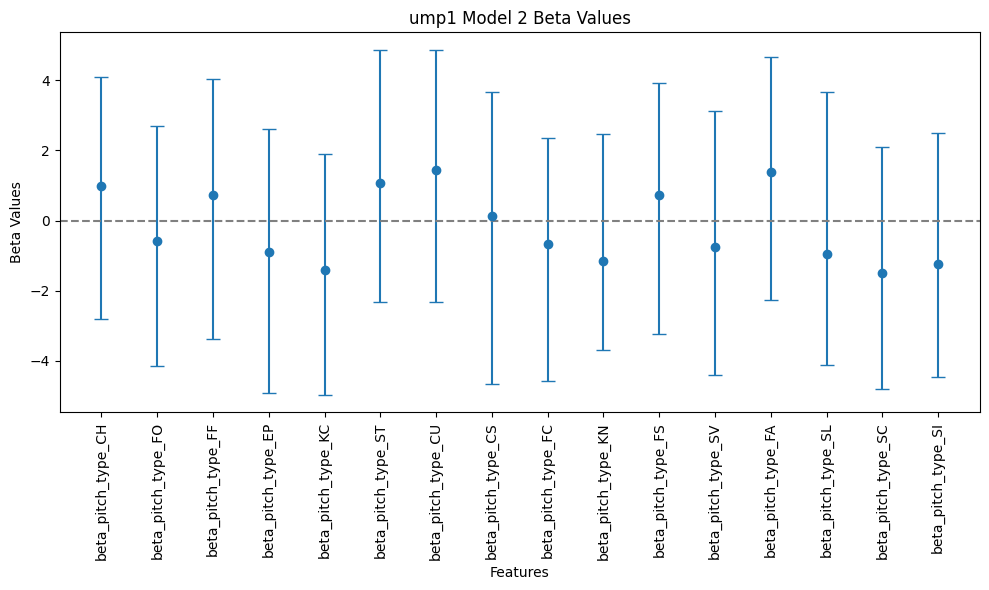

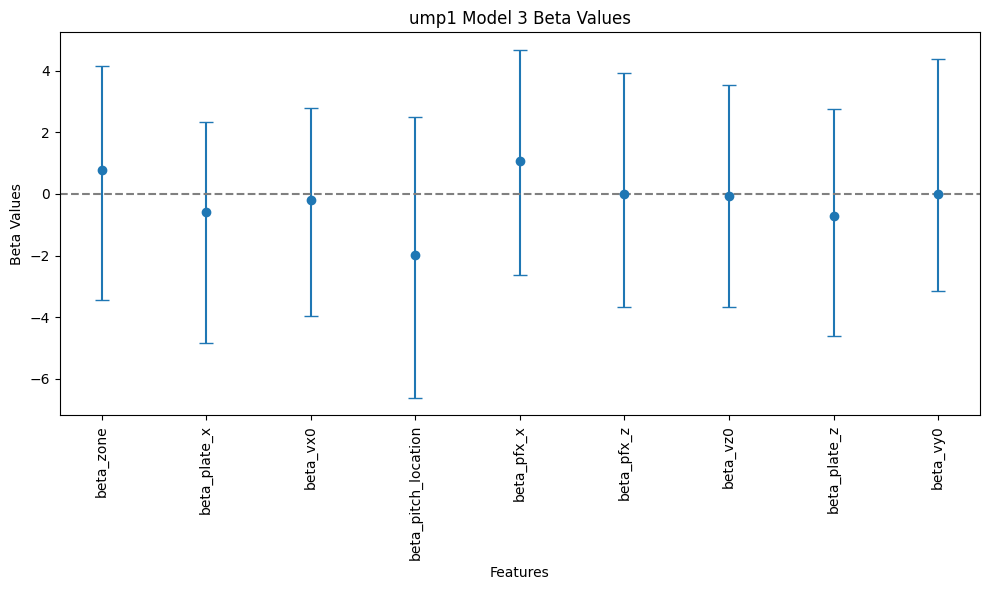

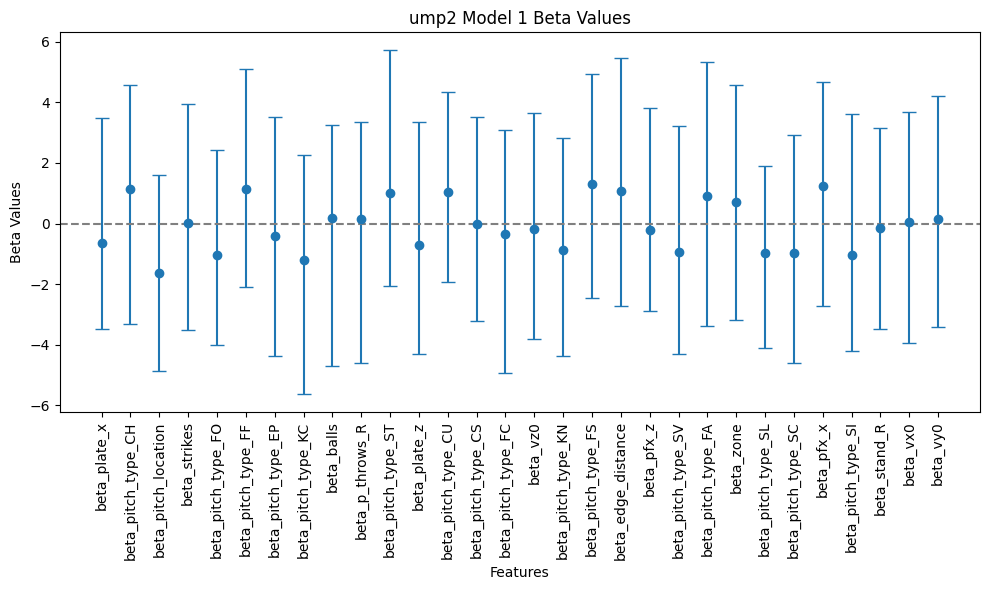

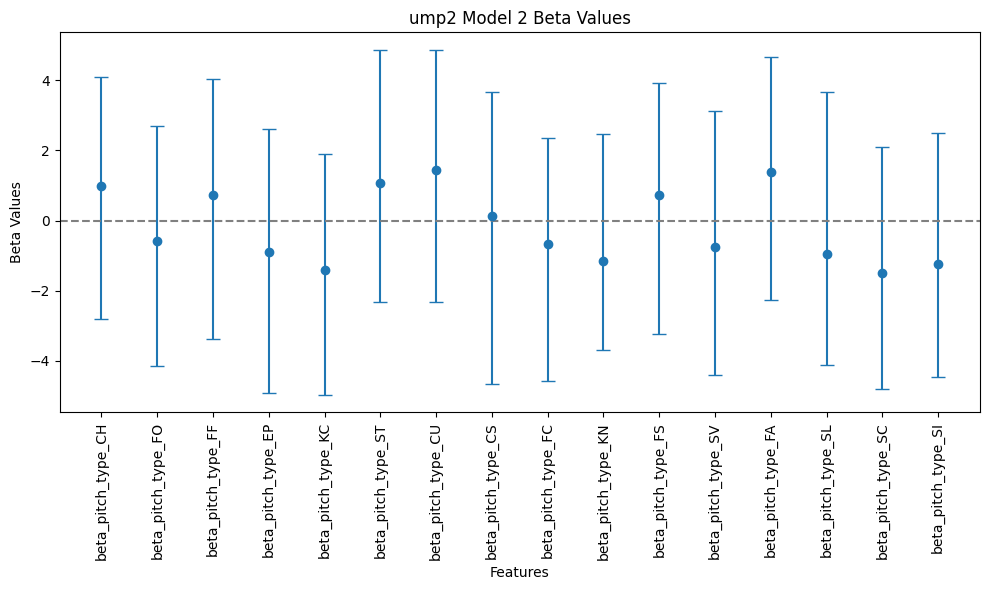

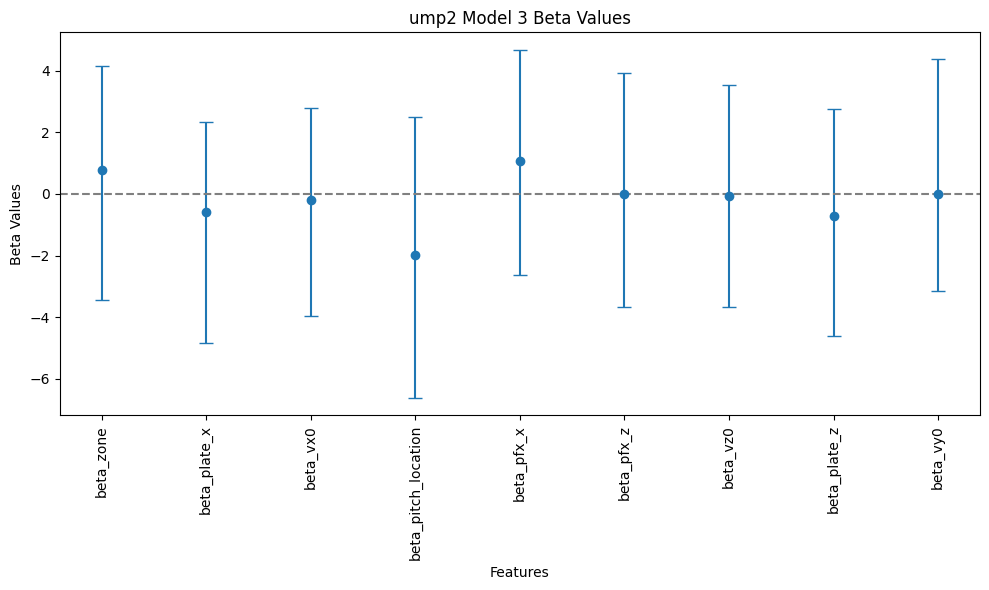

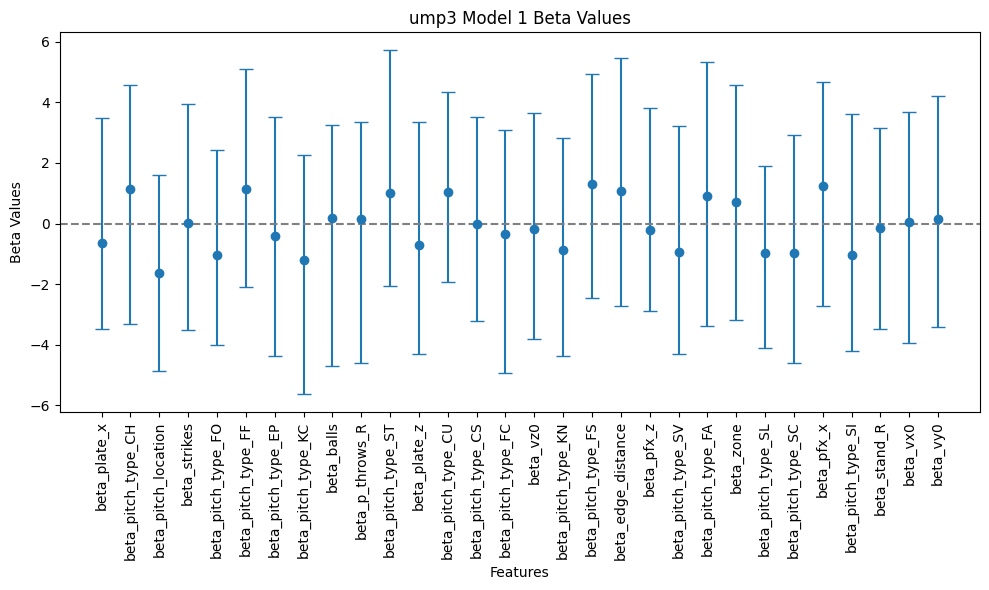

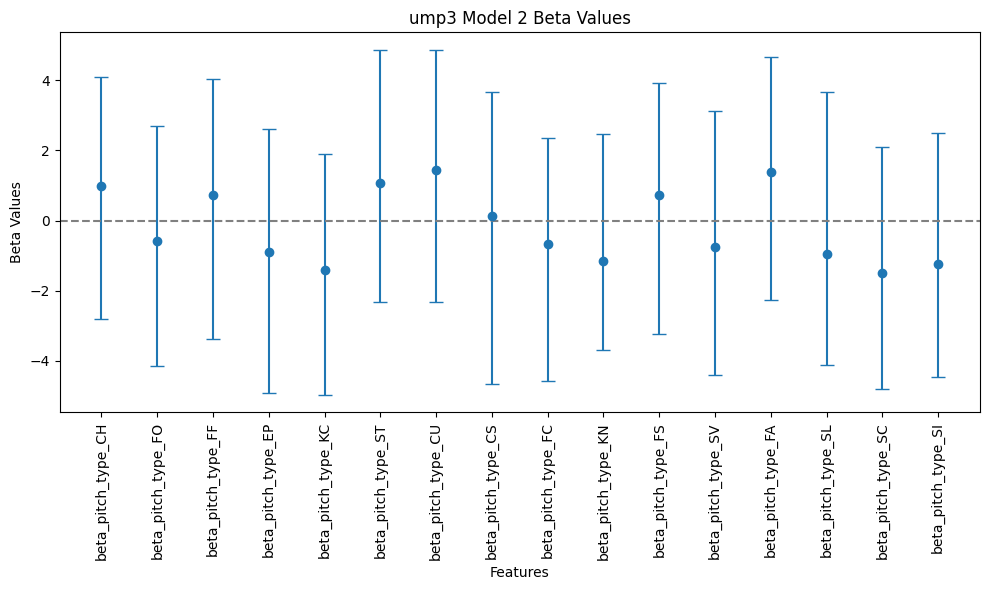

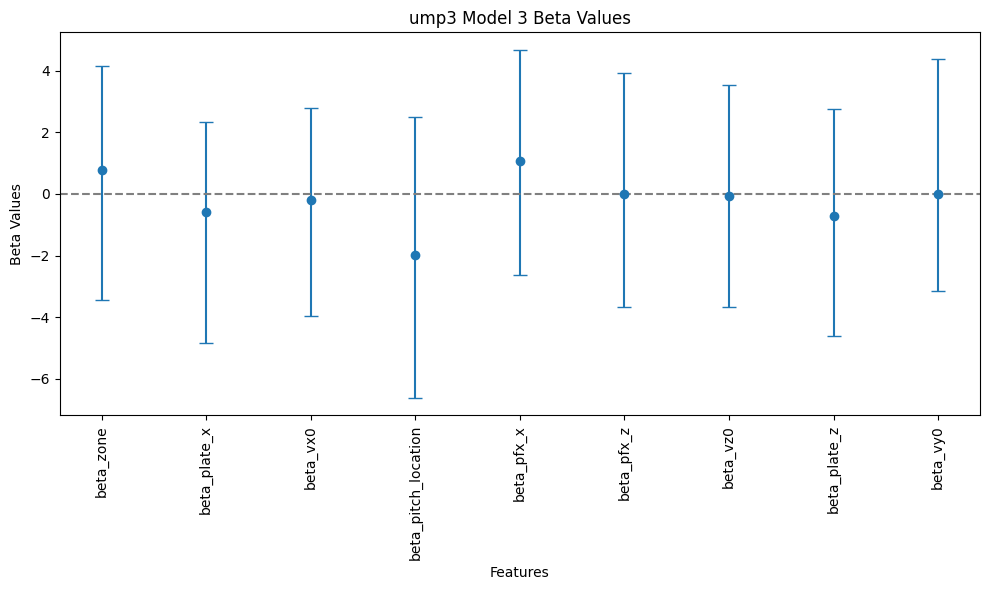

In [63]:
for ump_name, data in umpire_datasets.items():
    log_path = f"data/rebuild/{ump_name}_all_model_prior_summaries.txt"
    open(log_path, "w").close() # Clear previous logs

    with open(log_path, "a") as log_file:
        for index, (model_name, features) in enumerate(feature_sets.items()):
            print(f"\n\n\n---------- Printing {model_name} Summary ----------", file=log_file)
            print(summaries_priors[model_name], file=log_file)
        
            plt.figure(figsize=(10, 6))
            plt.errorbar(summaries_priors[model_name].index, summaries_priors[model_name]['mean'],
                        yerr=[summaries_priors[model_name]['mean'] - summaries_priors[model_name]['hdi_2.5%'], summaries_priors[model_name]['hdi_97.5%'] - summaries_priors[model_name]['mean']],
                        fmt='o', capsize=5)
            plt.axhline(0, color='gray', linestyle='--')
            plt.xlabel('Features')
            plt.ylabel('Beta Values')
            plt.title(f'{ump_name} Model {index + 1} Beta Values')
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()

## Step 4: Create Models

### 4.1 Balance out sampling for correct/incorrect calls

In [64]:
for ump_name, data in umpire_datasets.items():
    print(f"Class balance for {ump_name}:")
    print(data['error_in_decision'].value_counts(normalize=True))
    print("-" * 20)

Class balance for ump1:
error_in_decision
1    0.872457
0    0.127543
Name: proportion, dtype: float64
--------------------
Class balance for ump2:
error_in_decision
1    0.869118
0    0.130882
Name: proportion, dtype: float64
--------------------
Class balance for ump3:
error_in_decision
1    0.879078
0    0.120922
Name: proportion, dtype: float64
--------------------


In [65]:
def balance(df, feature_set, target):
    X = df[feature_set].values
    y = df[target].values

    strategy = [
        ('undersample', RandomUnderSampler(sampling_strategy={1: 20000}, random_state=5)),
        ('oversample', SMOTE(sampling_strategy={0: 20000}, random_state=5))
    ]

    pipeline = Pipeline(strategy)

    X_resampled, y_resampled = pipeline.fit_resample(X, y)


    return X_resampled, y_resampled

In [66]:
feature_sets = {
    "found_features_only": {
        'zone': 0.1, 'plate_x': 0.3, 'plate_z': 0.2,
        'pitch_location': 0.6, 'edge_distance': 0.3
    },
    "physical_features": {
        'vx0': 0.2, 'vy0': 0.2, 'zone': 0.1, 'plate_x': 0.3, 'plate_z': 0.2,
        'pitch_location': 0.6, 'edge_distance': 0.3
    },
    "OG_pos_features": {
        'zone': 0.1, 'plate_x': 0.3, 'plate_z': 0.2,
        'pitch_location': 0.6, 'edge_distance': 0.3,
        'stand_R': 0.1, 'p_throws_R': 0.1
    }
}

# Step 4: Sample Posterior & Save Context

In [67]:
from sklearn.metrics import confusion_matrix

def posterior_plot(data, trace, features, ump_file, model_name):
    X = data[features].values
    y_true = data['error_in_decision'].values

    intercept_samples = trace.posterior["β_0"].stack(sample=("chain", "draw")).values
    beta_samples = trace.posterior["β"].stack(sample=("chain", "draw")).values
    pred_probs = 1/ (1+np.exp(-(intercept_samples[:, None] + np.dot(beta_samples.T, X.T))))
    y_pred_mean = pred_probs.mean(axis=0)

    plt.figure(figsize=(8,4))
    plt.hist(y_pred_mean[y_true == 1], bins = 10, alpha = 0.6, label="Correct Calls", color='green', density=True)
    plt.hist(y_pred_mean[y_true == 0], bins = 10, alpha = 0.6, label="Incorrect Calls", color='red', density=True)
    plt.xlabel("Predicted Probability of Correct Call")
    plt.ylabel("Distribution")
    plt.title(f"Model {model_name} {ump_file} Posterior Predictive")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Confusion Matrix 
    y_pred_labels = (y_pred_mean > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred_labels)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Pred 0 (Incorrect)", "Pred 1 (Correct)"],
                yticklabels=["Actual 0 (Incorrect)", "Actual 1 (Correct)"])
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Model {model_name} {ump_file} Confusion Matrix (1 = Correct Call)")
    plt.tight_layout()
    plt.show()

In [71]:
for ump_num, data in umpire_datasets.items():
    for model_num, feature_dict in feature_sets.items():
        feature_names = list(feature_dict.keys())
        feature_mus = list(feature_dict.values())

        #def balance(df, feature_set, target)
        X_df, y_series = balance(data, feature_names, 'error_in_decision')

        # Convert to NumPy arrays
        X = np.asarray(X_df).astype("float64")
        y = np.asarray(y_series).astype("int8")  # 0/1 target for Binomial
        
        # Safety checks
        assert not np.isnan(X).any(), "NaNs found in X"
        assert not np.isinf(X).any(), "Infs found in X"
        assert not np.isnan(y).any(), "NaNs found in y"


        with pm.Model() as model:
            β_0 = pm.Normal("β_0", mu=0, sigma=1)
            β = pm.Normal("β", mu=feature_mus, sigma=1)

            logits = β_0 + pm.math.dot(X, β)
            theta = pm.Deterministic("theta", pm.math.sigmoid(logits))

            zi = pm.Beta("zi", alpha=2, beta=10)
            y_obs = pm.ZeroInflatedBinomial("y_obs", psi=zi, n=1, p=theta, observed=y)
            print(np.isnan(y).any())
            trace = pm.sample(300, core=1, tune=300, target_accept=0.95, return_inferencedata=True, random_seed=5)
            
            az.to_netcdf(trace, f"rdata/rebuild/{model_name}_traces.nc")

        posterior_plot(data, trace, feature_names, ump_num, model_num)

Initializing NUTS using jitter+adapt_diag...


False


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [β_0, β, zi]


Output()

EOFError: 

If context gets disrupted, add the traces back to local context! Run steps 1,2 again.

In [ ]:
for model_name in feature_sets:
    # rebuild traces
    trace_path = os.path.join("data/rebuild", f"{model_name}_traces.nc")
    
    if os.path.exists(trace_path):
        traces[model_name] = az.from_netcdf(trace_path)
        print(f"Loaded trace for: {model_name}")
    else:
        print(f"Trace file not found: {trace_path}")

In [ ]:
# Compare models
if len(traces) > 1:
    model_compare = az.compare(traces, ic="loo")
    display(model_compare)